# 09. Classification Metrics, Thresholds, and Confusion Matrices

A binary classifier predicts a label and proposes an action. Once a model outputs a score or probability, someone still has to decide what counts as "positive enough" to trigger an intervention. That is why classification evaluation is never only about one summary score. The same probability model can look cautious, aggressive, wasteful, or effective depending on the threshold that turns scores into decisions.

This notebook studies classification evaluation as a threshold-dependent decision problem. We begin with confusion matrices and the core metrics derived from them: precision, recall, specificity, false-positive rate, F1, and balanced accuracy. We then show how ROC and precision-recall curves summarize threshold tradeoffs at the score level. Finally, we tune thresholds under two operational constraints that appear constantly in practice: **asymmetric error costs** and **limited intervention capacity**.

The analytical framing follows several classic ideas. Fawcett (2006) gives the canonical introduction to ROC analysis. Saito and Rehmsmeier (2015) show why precision-recall analysis is often more informative under class imbalance. Flach (2019) emphasizes that evaluation measures should be linked to use cases rather than treated as generic gold standards. Ferri, Hernández-Orallo, and Flach (2019) show that threshold choice depends on operating conditions such as class distribution, calibration, and misclassification costs.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain how a confusion matrix changes when the classification threshold changes.
2. Distinguish among precision, recall, specificity, false-positive rate, F1, and balanced accuracy.
3. Explain why ROC and precision-recall curves answer related but different evaluation questions.
4. Recognize when accuracy becomes misleading under class imbalance.
5. Choose a threshold using business costs or intervention capacity rather than habit.
6. Interpret score-level model quality separately from decision-level threshold policy.


## 1. Classification Is a Thresholded Decision Rule

Suppose a model outputs an estimated risk score or probability \(\hat p_i\) for observation \(i\). To turn that score into a binary action, we choose a threshold \(t\) and classify

$$
\hat y_i(t) = \mathbb{1}[\hat p_i \ge t].
$$

Once the threshold is fixed, every prediction falls into one of four cells:

| | Actual positive | Actual negative |
|---|---:|---:|
| Predicted positive | TP | FP |
| Predicted negative | FN | TN |

From this confusion matrix we define several core metrics:

$$
\text{Precision} = \frac{TP}{TP + FP},
$$

$$
\text{Recall} = \frac{TP}{TP + FN},
$$

$$
\text{Specificity} = \frac{TN}{TN + FP},
$$

$$
\text{FPR} = \frac{FP}{FP + TN} = 1 - \text{Specificity},
$$

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.
$$

These metrics do not contradict one another. They highlight different consequences of the same decision rule.

| Metric | What it emphasizes | When it matters most |
|---|---|---|
| `Precision` | How many flagged cases are truly positive | Outreach capacity is scarce and false alarms are expensive |
| `Recall` | How many actual positives we catch | Missing a positive case is very costly |
| `Specificity` | How often negatives stay unflagged | The organization wants to avoid unnecessary intervention |
| `FPR` | False alarms among negatives | Large negative class makes false alarms easy to hide |
| `F1` | Balance of precision and recall | We want one summary of minority-class detection |
| `Balanced accuracy` | Mean of recall and specificity | Accuracy is distorted by imbalance |

The threshold is therefore not a cosmetic setting. It defines the operating policy.


In [1]:
# Section focus: 1. Classification Is a Thresholded Decision Rule.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

sns.set_theme(style='whitegrid', palette='crest')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

rng = np.random.default_rng(12)


def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def classification_summary(y_true, scores, threshold):
    """Carry out the classification summary step used in the 09. Classification Metrics, Thresholds, and Confusion Matrices workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    threshold : object
        Decision cutoff used to convert scores into actions or alerts.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return {
        'threshold': threshold,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'alert_rate': y_pred.mean(),
        'alerts': int(y_pred.sum()),
    }


def weighted_classification_cost(y_true, scores, threshold, fn_cost=25.0, fp_cost=4.0):
    """Carry out the weighted classification cost step used in the 09. Classification Metrics, Thresholds, and Confusion Matrices workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    threshold : object
        Decision cutoff used to convert scores into actions or alerts.
    fn_cost : object
        Cost value used to translate model errors into operational consequences.
    fp_cost : object
        Cost value used to translate model errors into operational consequences.
    
    Returns
    -------
    object
        Intermediate result produced by the weighted classification cost calculation and reused by later cells.
    """
    stats = classification_summary(y_true, scores, threshold)
    return fn_cost * stats['fn'] + fp_cost * stats['fp']


## 2. Synthetic Rare-Event Intervention Dataset

We will work with a binary prediction problem in customer operations: **which enterprise accounts are at risk of an SLA breach next week?**

This is a good classification example because it has all the ingredients that make evaluation subtle:

- the positive class is relatively rare,
- intervention capacity is limited,
- false negatives are expensive because missed breaches damage service commitments,
- false positives are not free because specialists spend time reviewing accounts that may have been fine.

The predictors are deliberately operational rather than abstract:

- `backlog_ratio`: unresolved support load relative to normal throughput,
- `usage_drop_30d`: recent engagement deterioration,
- `minor_incidents_30d`: repeated small warnings before a major issue,
- `self_service_failures_30d`: inability of customers to resolve issues via self-service,
- `payment_hold`: administrative friction that often co-travels with support problems,
- `release_wave`: product changes that increase the stress level of the system,
- `support_touch_count_30d`, `tier_score`, and `tenure_months`.

The outcome is binary: `sla_breach_next_week = 1` if the account enters an SLA-breach state next week.


,split,rows,breach_rate,release_share,payment_hold_share
0,Test,1200,0.198,0.300,0.087
1,Train,4800,0.175,0.225,0.076
2,Validation,1200,0.188,0.300,0.073


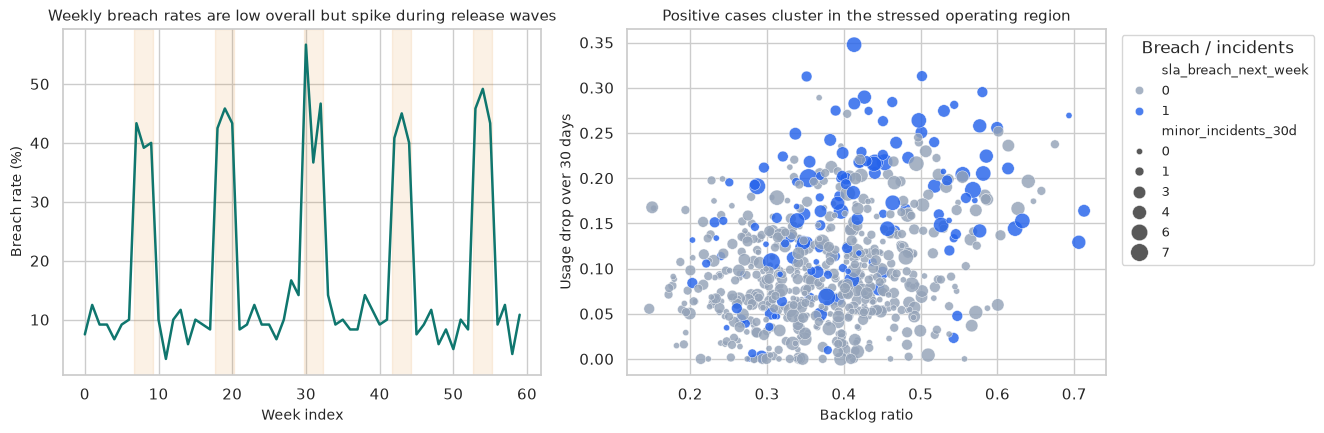

In [2]:

weeks = 60
accounts_per_week = 120
n = weeks * accounts_per_week

week_index = np.repeat(np.arange(weeks), accounts_per_week)
df = pd.DataFrame({'week_index': week_index})
df['cohort_date'] = pd.Timestamp('2024-01-01') + pd.to_timedelta(df['week_index'] * 7, unit='D')

release_wave = np.zeros(n)
for center in [8, 19, 31, 43, 54]:
    release_wave += np.exp(-((df['week_index'] - center) ** 2) / (2 * 1.7 ** 2))
df['release_wave'] = (release_wave > 0.55).astype(int)

# Account features.
df['tier_score'] = rng.choice([0, 1, 2], size=n, p=[0.45, 0.37, 0.18])
df['tenure_months'] = np.clip(rng.normal(28, 14, n), 2, 84)
df['payment_hold'] = rng.binomial(1, 0.06 + 0.04 * (df['tier_score'] == 0))

df['usage_drop_30d'] = np.clip(
    0.04
    + 0.09 * rng.beta(2.0, 5.0, n)
    + 0.11 * df['release_wave']
    + 0.08 * df['payment_hold']
    + 0.02 * (df['tier_score'] == 0)
    + rng.normal(0, 0.04, n),
    0,
    0.55,
)

df['backlog_ratio'] = np.clip(
    0.20
    + 0.38 * rng.beta(2.2, 3.5, n)
    + 0.12 * df['release_wave']
    + 0.06 * (df['tier_score'] == 2)
    + rng.normal(0, 0.05, n),
    0.02,
    1.20,
)

df['minor_incidents_30d'] = rng.poisson(
    np.clip(0.8 + 1.0 * df['release_wave'] + 1.2 * df['backlog_ratio'], 0.05, None)
)

df['self_service_failures_30d'] = rng.poisson(
    np.clip(0.4 + 4.5 * df['usage_drop_30d'] + 0.8 * df['release_wave'], 0.05, None)
)

df['support_touch_count_30d'] = rng.poisson(
    np.clip(1.8 + 4.0 * df['backlog_ratio'] + 1.8 * df['usage_drop_30d'] + 0.9 * df['payment_hold'], 0.1, None)
)

# Latent breach risk.
logit = (
    -4.1
    + 2.2 * df['backlog_ratio']
    + 5.2 * df['usage_drop_30d']
    + 0.30 * df['minor_incidents_30d']
    + 0.25 * df['self_service_failures_30d']
    + 1.10 * df['payment_hold']
    + 0.55 * df['release_wave']
    + 0.25 * (df['tier_score'] == 2)
    - 0.010 * df['tenure_months']
    + 1.10 * ((df['backlog_ratio'] > 0.68) & (df['release_wave'] == 1)).astype(int)
    + 0.80 * ((df['usage_drop_30d'] > 0.22) & (df['minor_incidents_30d'] >= 2)).astype(int)
    + 0.65 * ((df['payment_hold'] == 1) & (df['support_touch_count_30d'] >= 5)).astype(int)
)

true_prob = sigmoid(logit)
df['sla_breach_next_week'] = rng.binomial(1, true_prob)

df['operating_regime'] = np.select(
    [
        df['release_wave'] == 1,
        df['payment_hold'] == 1,
        df['backlog_ratio'] > 0.70,
    ],
    ['Release wave', 'Payment hold', 'High backlog'],
    default='Routine'
)

# Time-based split.
df['split'] = np.select(
    [df['week_index'] < 40, df['week_index'] < 50],
    ['Train', 'Validation'],
    default='Test'
)

prevalence_table = (
    df.groupby('split', as_index=False)
      .agg(
          rows=('sla_breach_next_week', 'size'),
          breach_rate=('sla_breach_next_week', 'mean'),
          release_share=('release_wave', 'mean'),
          payment_hold_share=('payment_hold', 'mean'),
      )
)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.5))

weekly_rate = df.groupby('week_index', as_index=False)['sla_breach_next_week'].mean()
axes[0].plot(weekly_rate['week_index'], 100 * weekly_rate['sla_breach_next_week'], color='#0f766e', linewidth=1.8)
for center in [8, 19, 31, 43, 54]:
    axes[0].axvspan(center - 1.3, center + 1.3, color='#d97706', alpha=0.10)
axes[0].set_title('Weekly breach rates are low overall but spike during release waves')
axes[0].set_xlabel('Week index')
axes[0].set_ylabel('Breach rate (%)')

sampled = df.sample(700, random_state=0)
sns.scatterplot(
    data=sampled,
    x='backlog_ratio',
    y='usage_drop_30d',
    hue='sla_breach_next_week',
    size='minor_incidents_30d',
    sizes=(20, 180),
    palette=['#94a3b8', '#2563eb'],
    alpha=0.82,
    ax=axes[1],
)
axes[1].set_title('Positive cases cluster in the stressed operating region')
axes[1].set_xlabel('Backlog ratio')
axes[1].set_ylabel('Usage drop over 30 days')
axes[1].legend(title='Breach / incidents', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
prevalence_table


In Synthetic Rare-Event Intervention Dataset, the point of the output is practical. The point is to leave the analyst with a more precise next step.


### Discussion of the Dataset

This is a deliberately imbalanced intervention problem. Most accounts do **not** breach SLA next week, so a naive classifier that predicts "negative" most of the time can still look good on raw accuracy. That is exactly why threshold-aware metrics matter.

The second plot also previews an important modeling reality: positive cases are concentrated in stressed regions of the feature space rather than being uniformly scattered. That gives nonlinear models room to improve ranking quality, but it does not remove the need for careful threshold policy.

The dataset is also designed to make the intervention constraint visible. The classifier is not being built for curiosity; it supports a review queue. That means the relevant question asks whether the model separates positive and negative cases, how many high-risk accounts the team can inspect, and what happens when the threshold moves.

The simulated labels are useful because we can evaluate misses and false alarms directly. In a real support organization, breach labels may arrive after investigation, and some near-misses may never be recorded. The clean label column in the notebook is therefore a teaching convenience, not a claim about how easy classification evaluation is in production.


## 3. Score-Level Model Comparison Before Threshold Choice

We first compare several models at the **score** level, meaning we look at how well they rank risky accounts before turning probabilities into hard decisions.

The models are:

1. `Dummy (prior)` baseline,
2. `Logistic` regression,
3. `Random forest`,
4. `HistGB` gradient boosting.

At this stage, the two most useful summary measures are:

- **ROC AUC**, which summarizes ranking quality through true-positive vs false-positive tradeoffs across thresholds (Fawcett, 2006),
- **Average precision**, which is closely tied to the precision-recall curve and is often more revealing under imbalance (Saito & Rehmsmeier, 2015).

We also report the default-threshold metrics at `0.50`, not because `0.50` is intrinsically correct, but because it helps show how arbitrary that convention can be.


In [3]:
# Section focus: 3. Score-Level Model Comparison Before Threshold Choice.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


feature_cols = [
    'tier_score',
    'tenure_months',
    'payment_hold',
    'usage_drop_30d',
    'backlog_ratio',
    'minor_incidents_30d',
    'self_service_failures_30d',
    'support_touch_count_30d',
    'release_wave',
]

target_col = 'sla_breach_next_week'

train = df[df['split'] == 'Train'].copy()
validation = df[df['split'] == 'Validation'].copy()
test = df[df['split'] == 'Test'].copy()

X_train, y_train = train[feature_cols], train[target_col]
X_validation, y_validation = validation[feature_cols], validation[target_col]
X_test, y_test = test[feature_cols], test[target_col]

default_threshold = 0.50

models = {
    'Dummy (prior)': DummyClassifier(strategy='prior'),
    'Logistic': Pipeline([
        ('scale', StandardScaler()),
        ('logit', LogisticRegression(max_iter=1500, C=1.0)),
    ]),
    'Random forest': RandomForestClassifier(
        n_estimators=450,
        min_samples_leaf=5,
        max_depth=None,
        random_state=0,
        n_jobs=-1,
    ),
    'HistGB': HistGradientBoostingClassifier(
        max_depth=5,
        learning_rate=0.05,
        max_iter=320,
        min_samples_leaf=25,
        l2_regularization=0.08,
        random_state=0,
    ),
}

predictions = {}
score_rows = []
for model_name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    val_scores = fitted.predict_proba(X_validation)[:, 1]
    test_scores = fitted.predict_proba(X_test)[:, 1]
    predictions[model_name] = {
        'validation_scores': val_scores,
        'test_scores': test_scores,
        'fitted_model': fitted,
    }
    for split_name, y_true, scores in [('Validation', y_validation, val_scores), ('Test', y_test, test_scores)]:
        stats_050 = classification_summary(y_true, scores, default_threshold)
        score_rows.append({
            'model': model_name,
            'split': split_name,
            'roc_auc': roc_auc_score(y_true, scores),
            'average_precision': average_precision_score(y_true, scores),
            'accuracy_at_0p50': stats_050['accuracy'],
            'precision_at_0p50': stats_050['precision'],
            'recall_at_0p50': stats_050['recall'],
            'f1_at_0p50': stats_050['f1'],
            'alert_rate_at_0p50': stats_050['alert_rate'],
        })

score_table = pd.DataFrame(score_rows)
score_table_test = score_table.query("split == 'Test'").sort_values('average_precision', ascending=False).reset_index(drop=True)
score_table_test


,model,split,roc_auc,average_precision,accuracy_at_0p50,precision_at_0p50,recall_at_0p50,f1_at_0p50,alert_rate_at_0p50
0,Logistic,Test,0.843,0.634,0.845,0.669,0.433,0.526,0.128
1,Random forest,Test,0.839,0.631,0.846,0.669,0.441,0.532,0.131
2,HistGB,Test,0.824,0.607,0.840,0.635,0.454,0.529,0.142
3,Dummy (prior),Test,0.500,0.198,0.802,0.000,0.000,0.000,0.000


Score-Level Model Comparison Before Threshold Choice gives a checkpoint for the decision workflow. The strongest signal is the one that would redirect the next step.


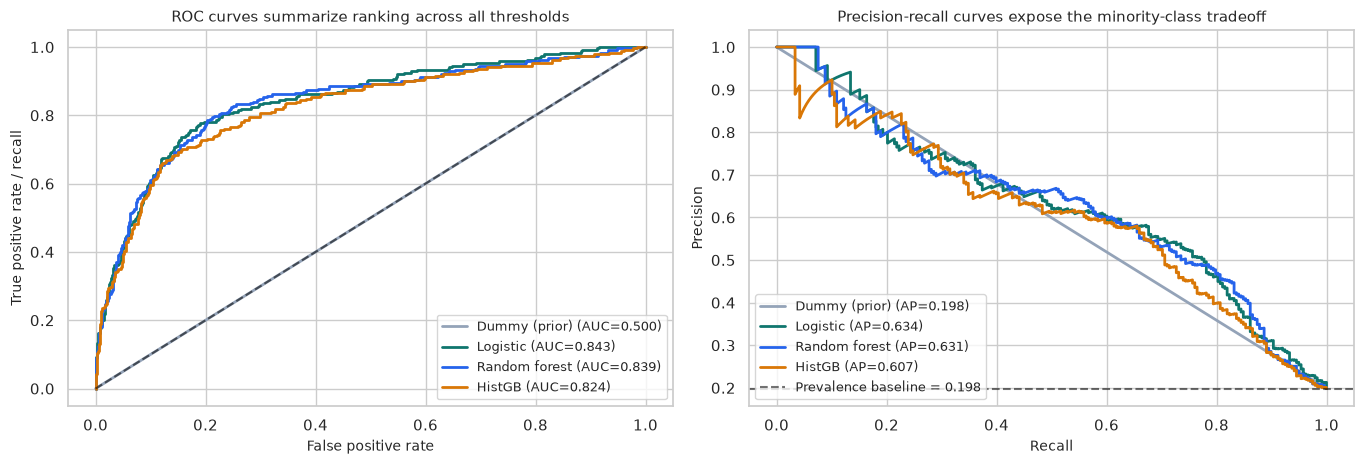

In [4]:
# Section focus: 3. Score-Level Model Comparison Before Threshold Choice.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


positive_prevalence = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8))

for model_name, color in zip(['Dummy (prior)', 'Logistic', 'Random forest', 'HistGB'], ['#94a3b8', '#0f766e', '#2563eb', '#d97706']):
    scores = predictions[model_name]['test_scores']
    fpr, tpr, _ = roc_curve(y_test, scores)
    precision, recall, _ = precision_recall_curve(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)
    axes[0].plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)
    axes[1].plot(recall, precision, label=f'{model_name} (AP={ap:.3f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.55)
axes[0].set_title('ROC curves summarize ranking across all thresholds')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate / recall')
axes[0].legend(loc='lower right')

axes[1].axhline(positive_prevalence, linestyle='--', color='black', alpha=0.55, label=f'Prevalence baseline = {positive_prevalence:.3f}')
axes[1].set_title('Precision-recall curves expose the minority-class tradeoff')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()


The Score-Level Model Comparison Before Threshold Choice result matters when it changes the next move. Focus on the evidence with consequences for model selection or governance.


### Discussion of the Score-Level Comparison

This table separates two questions that are often blurred together.

1. **Can the model rank risky cases well?** That is what ROC AUC and average precision are primarily about.
2. **What happens if we classify at `0.50`?** That is a decision-policy question, not a pure model-quality question.

This distinction matters a lot under imbalance. A model can have a respectable ROC AUC while a `0.50` threshold produces poor recall. Likewise, the precision-recall curve can reveal a much harsher tradeoff than the ROC curve because false positives matter more visibly when positives are rare. That is the core point emphasized by Saito and Rehmsmeier (2015).


## 4. Threshold Policies for the Champion Model

We now take the best-performing score model and examine several threshold policies on top of it. We choose the champion using **validation average precision**, then define four threshold rules:

1. `Default 0.50`
2. `Best F1 on validation`
3. `Lowest weighted cost on validation`
4. `Highest recall subject to review capacity`

The last two policies require explicit operating assumptions. We will use:

- false negative cost = `25`
- false positive cost = `4`
- maximum review capacity = `12%` of accounts

These values are illustrative, but the logic is real: thresholds should follow the decision environment, not habit.


In [5]:
# Section focus: 4. Threshold Policies for the Champion Model.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


champion_name = (
    score_table.query("split == 'Validation'")
               .sort_values('average_precision', ascending=False)
               .iloc[0]['model']
)

val_scores = predictions[champion_name]['validation_scores']
test_scores = predictions[champion_name]['test_scores']

fn_cost = 25.0
fp_cost = 4.0
capacity_rate = 0.12
threshold_grid = np.linspace(0.02, 0.95, 140)

threshold_rows = []
for threshold in threshold_grid:
    stats = classification_summary(y_validation, val_scores, threshold)
    stats['weighted_cost'] = weighted_classification_cost(y_validation, val_scores, threshold, fn_cost=fn_cost, fp_cost=fp_cost)
    threshold_rows.append(stats)

threshold_curve = pd.DataFrame(threshold_rows)

threshold_default = 0.50
threshold_f1 = threshold_curve.loc[threshold_curve['f1'].idxmax(), 'threshold']
threshold_cost = threshold_curve.loc[threshold_curve['weighted_cost'].idxmin(), 'threshold']
capacity_candidates = threshold_curve[threshold_curve['alert_rate'] <= capacity_rate].copy()
threshold_capacity = capacity_candidates.sort_values(['recall', 'weighted_cost'], ascending=[False, True]).iloc[0]['threshold']

selected_thresholds = {
    'Default 0.50': threshold_default,
    'Best F1': threshold_f1,
    'Cost-optimal': threshold_cost,
    'Capacity-constrained': threshold_capacity,
}

policy_rows = []
for name, threshold in selected_thresholds.items():
    stats = classification_summary(y_test, test_scores, threshold)
    stats.update({
        'policy': name,
        'weighted_cost': weighted_classification_cost(y_test, test_scores, threshold, fn_cost=fn_cost, fp_cost=fp_cost),
    })
    policy_rows.append(stats)

policy_table = pd.DataFrame(policy_rows)[[
    'policy', 'threshold', 'alerts', 'alert_rate', 'tp', 'fp', 'fn', 'tn',
    'precision', 'recall', 'specificity', 'f1', 'balanced_accuracy', 'weighted_cost'
]].sort_values('weighted_cost').reset_index(drop=True)

pd.DataFrame({'champion_model': [champion_name], 'test_prevalence': [positive_prevalence], 'fn_cost': [fn_cost], 'fp_cost': [fp_cost], 'capacity_rate': [capacity_rate]})


,champion_model,test_prevalence,fn_cost,fp_cost,capacity_rate
0,Logistic,0.198,25.000,4.000,0.120


Read Threshold Policies for the Champion Model as a decision checkpoint. The pattern earns attention when it changes the next analytical step.


In [6]:

policy_table


,policy,threshold,alerts,alert_rate,tp,fp,fn,tn,precision,recall,specificity,f1,balanced_accuracy,weighted_cost
0,Cost-optimal,0.147,485,0.404,198,287,40,675,0.408,0.832,0.702,0.548,0.767,"2,148.000"
1,Best F1,0.301,321,0.268,173,148,65,814,0.539,0.727,0.846,0.619,0.787,"2,217.000"
2,Default 0.50,0.500,154,0.128,103,51,135,911,0.669,0.433,0.947,0.526,0.690,"3,579.000"
3,Capacity-constrained,0.502,149,0.124,99,50,139,912,0.664,0.416,0.948,0.512,0.682,"3,675.000"


The practical question in Threshold Policies for the Champion Model is simple. What would this result make the analyst do differently?


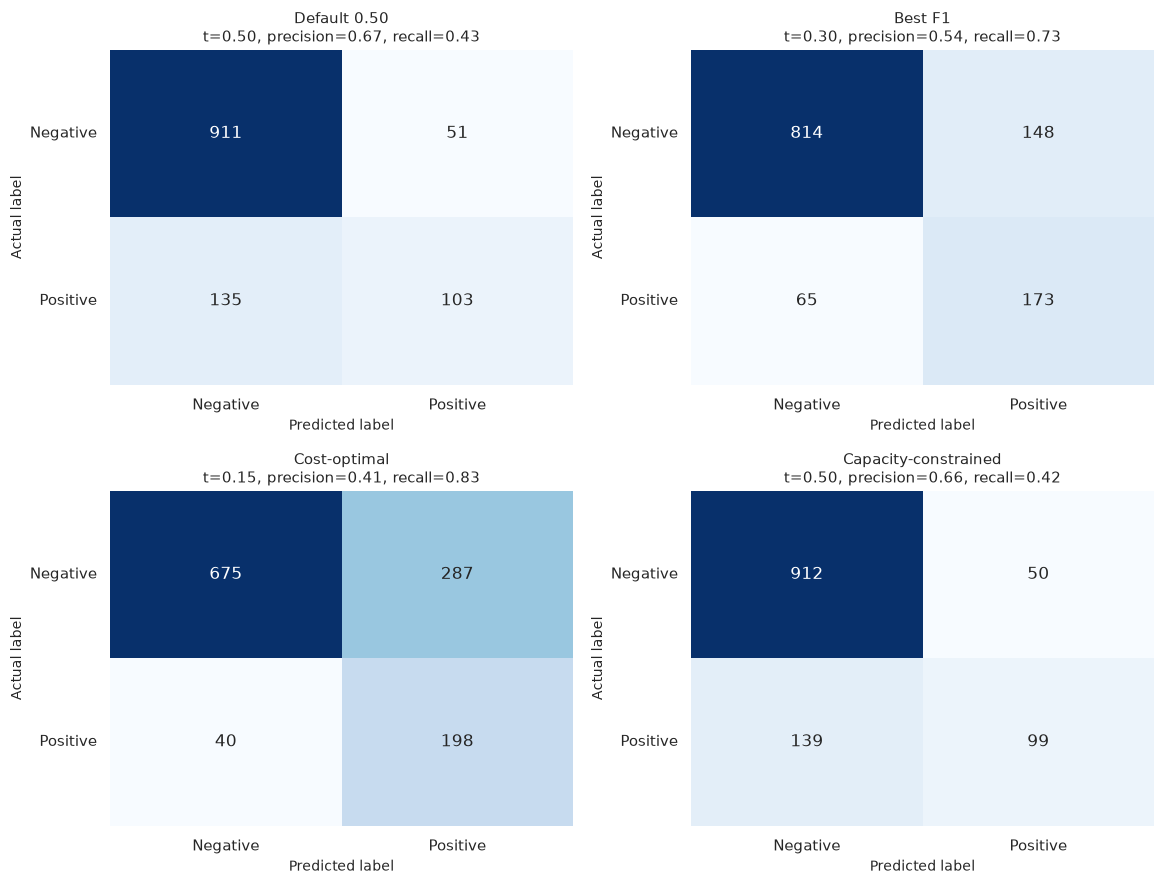

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(11.8, 9.0))
axes = axes.flatten()

for ax, (policy_name, threshold) in zip(axes, selected_thresholds.items()):
    y_pred = (test_scores >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    stats = classification_summary(y_test, test_scores, threshold)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(
        f"{policy_name}\n"
        f"t={threshold:.2f}, precision={stats['precision']:.2f}, recall={stats['recall']:.2f}"
    )
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Actual label')
    ax.set_xticklabels(['Negative', 'Positive'])
    ax.set_yticklabels(['Negative', 'Positive'], rotation=0)

plt.tight_layout()


Use the Threshold Policies for the Champion Model output to decide what the analysis should do next. Use the pattern to decide whether the model, diagnostic plan, threshold, or guardrail needs revision.


### Discussion of the Confusion Matrices

These confusion matrices make the threshold tradeoff tangible.

- A **lower threshold** usually increases recall because more cases are flagged, but it also increases false positives.
- A **higher threshold** usually improves precision and specificity, but can miss too many true positives.
- The **best F1 threshold** is not guaranteed to be the cheapest threshold.
- The **capacity-constrained threshold** may look harsh, but it reflects a real operational fact: some organizations simply cannot review every risky-looking case.

This is exactly why the confusion matrix should be read as a policy summary.


## 5. Threshold Sweeps, Cost Curves, and Intervention Capacity

Threshold tuning should be done on validation data rather than on the test set. We therefore use the champion model's validation scores to map the whole operating frontier.

We will examine two complementary views:

1. how precision, recall, specificity, and alert rate move as the threshold changes,
2. how weighted cost changes as the threshold changes.

We then translate the same score ranking into a **top-k intervention** policy, where the team reviews only the highest-risk `k%` of accounts.


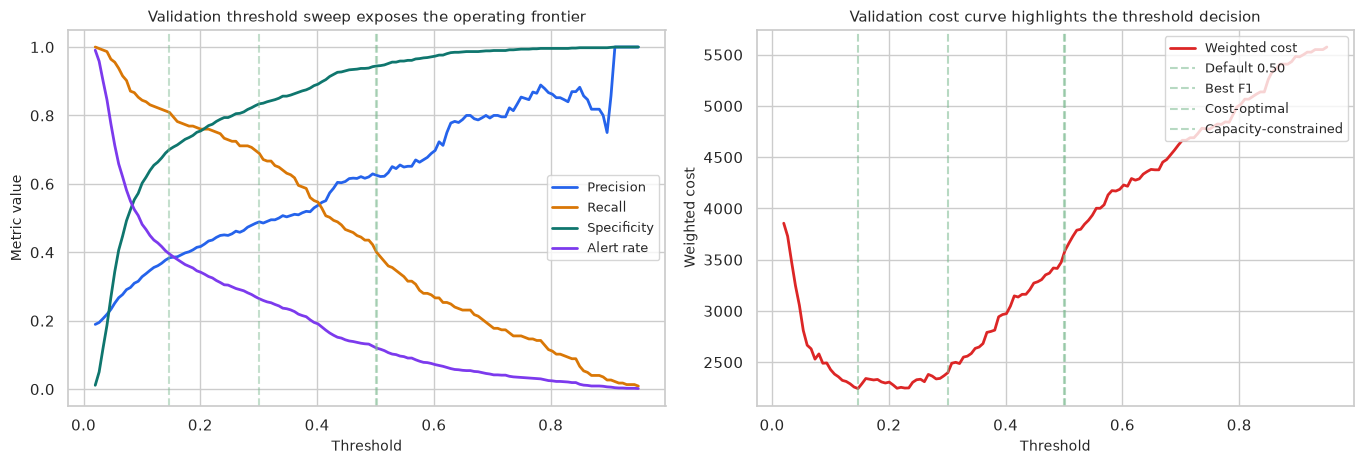

In [8]:
# Section focus: 5. Threshold Sweeps, Cost Curves, and Intervention Capacity.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8))

axes[0].plot(threshold_curve['threshold'], threshold_curve['precision'], label='Precision', color='#2563eb', linewidth=2)
axes[0].plot(threshold_curve['threshold'], threshold_curve['recall'], label='Recall', color='#d97706', linewidth=2)
axes[0].plot(threshold_curve['threshold'], threshold_curve['specificity'], label='Specificity', color='#0f766e', linewidth=2)
axes[0].plot(threshold_curve['threshold'], threshold_curve['alert_rate'], label='Alert rate', color='#7c3aed', linewidth=2)
for name, threshold in selected_thresholds.items():
    axes[0].axvline(threshold, linestyle='--', alpha=0.45)
axes[0].set_title('Validation threshold sweep exposes the operating frontier')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Metric value')
axes[0].legend(loc='center right')

axes[1].plot(threshold_curve['threshold'], threshold_curve['weighted_cost'], color='#dc2626', linewidth=2, label='Weighted cost')
for name, threshold in selected_thresholds.items():
    axes[1].axvline(threshold, linestyle='--', alpha=0.55, label=name)
axes[1].set_title('Validation cost curve highlights the threshold decision')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Weighted cost')
handles, labels = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), loc='upper right')

plt.tight_layout()


In Threshold Sweeps, Cost Curves, and Intervention Capacity, the point of the output is practical. The best reading turns the result into a modeling, diagnostic, threshold, or governance decision.


In [9]:

topk_rows = []
for rate in [0.05, 0.10, 0.12, 0.15, 0.20]:
    threshold = np.quantile(test_scores, 1 - rate)
    stats = classification_summary(y_test, test_scores, threshold)
    topk_rows.append({
        'review_rate': rate,
        'threshold': threshold,
        'alerts': stats['alerts'],
        'precision': stats['precision'],
        'recall': stats['recall'],
        'lift_vs_prevalence': stats['precision'] / positive_prevalence if positive_prevalence > 0 else np.nan,
        'weighted_cost': weighted_classification_cost(y_test, test_scores, threshold, fn_cost=fn_cost, fp_cost=fp_cost),
    })

topk_table = pd.DataFrame(topk_rows)
topk_table


,review_rate,threshold,alerts,precision,recall,lift_vs_prevalence,weighted_cost
0,0.050,0.693,60,0.800,0.202,4.034,"4,798.000"
1,0.100,0.554,120,0.717,0.361,3.613,"3,936.000"
2,0.120,0.505,144,0.681,0.412,3.431,"3,684.000"
3,0.150,0.466,180,0.639,0.483,3.221,"3,335.000"
4,0.200,0.386,240,0.596,0.601,3.004,"2,763.000"


Threshold Sweeps, Cost Curves, and Intervention Capacity gives a checkpoint for the decision workflow. This should help decide where the workflow needs attention next.


### Discussion of Threshold Tuning

This section usually changes how people think about classification.

A threshold is not a property of the model. It is a **decision setting** placed on top of the model. Ferri, Hernández-Orallo, and Flach (2019) emphasize exactly this point: threshold choice depends on operating conditions such as class balance, cost asymmetry, and deployment context.

The top-k table is especially useful in practice. Many teams do not literally ask for "the best threshold." They ask questions like:

- "What happens if we can only review 10% of accounts?"
- "How much recall do we get if the escalation team can handle 15 cases a week?"
- "How much lift over the base rate do we get in the intervention queue?"

Those are threshold questions expressed in business language.


## 6. Practical Checklist

| Question | Why it matters |
|---|---|
| What is the positive event and how rare is it? | Imbalance strongly affects metric interpretation |
| Are we evaluating scores or hard decisions? | ROC/PR quality and threshold policy are not the same thing |
| What is the cost of a false negative vs a false positive? | Threshold choice should reflect this asymmetry |
| Is `0.50` actually justified? | It often is not |
| Is intervention capacity limited? | Then top-k or alert-rate constrained policies matter |
| Are we choosing thresholds on validation rather than test data? | Test-optimized thresholds are optimistic |
| Are we reporting prevalence alongside precision? | Precision is hard to interpret without the base rate |
| Are we using PR analysis for rare positives? | ROC alone can look overly reassuring |

A good classification workflow therefore separates **model ranking**, **threshold policy**, and **operational capacity** instead of collapsing them into one number.


## Wrap-Up

This notebook treated binary classification as a thresholded decision problem rather than a mere label-prediction exercise. We used confusion matrices to define precision, recall, specificity, false-positive rate, F1, and balanced accuracy, then compared several models using ROC AUC and average precision before committing to any threshold.

The operational lesson is the important one. A classifier can produce useful risk scores while a default threshold still performs poorly. Once we tuned thresholds using validation data, we saw that different policies emerged depending on whether the goal was balanced detection, low weighted cost, or high recall under a limited review budget. That is how classification evaluation should work in decision settings: the model supplies the ranking, but the organization still has to choose the operating rule.

## References

- Fawcett, T. (2006). *An introduction to ROC analysis.* *Pattern Recognition Letters, 27*(8), 861-874. [https://doi.org/10.1016/j.patrec.2005.10.010](https://doi.org/10.1016/j.patrec.2005.10.010)
- Saito, T., & Rehmsmeier, M. (2015). *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets.* *PLOS ONE, 10*(3), e0118432. [https://doi.org/10.1371/journal.pone.0118432](https://doi.org/10.1371/journal.pone.0118432)
- Flach, P. (2019). *Performance Evaluation in Machine Learning: The Good, the Bad, the Ugly, and the Way Forward.* *Proceedings of the AAAI Conference on Artificial Intelligence, 33*(1), 9808-9814. [https://doi.org/10.1609/aaai.v33i01.33019808](https://doi.org/10.1609/aaai.v33i01.33019808)
- Ferri, C., Hernández-Orallo, J., & Flach, P. (2019). *Setting decision thresholds when operating conditions are uncertain.* *Data Mining and Knowledge Discovery, 33*(4), 805-847. [https://doi.org/10.1007/s10618-019-00613-7](https://doi.org/10.1007/s10618-019-00613-7)
